In [41]:
#Functions and packages

#Import bundle sampling and analysis functions
%run '/Users/bradturow/Desktop/Circle Bundle Code/Circle Bundle Algorithm Functions.ipynb'
%run '/Users/bradturow/Desktop/Circle Bundle Code/Synthetic Bundle Sampling Functions.ipynb'
%run '/Users/bradturow/Desktop/Circle Bundle Code/Visualizer Functions.ipynb'

#For saving
folder_path = '/Users/bradturow/Desktop/Diagrams/Clean_Diagrams/'

# Visualize The Adams Flow Torus

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def lattice_vis(
    data,
    coords,
    vis_func,
    per_row=7,
    per_col=7,
    padding=0.05,
    figsize=10,
    thumb_px=200,
    dpi=200,
    save_path=None
):
    """
    Plot images at (scaled) coordinates in [0,1]^2, while ensuring thumbnails
    are always fully visible (no clipping / scrunching at borders).

    Key behavior:
    - Selection is done by nearest neighbors to a lattice of target points
      (constructed using padding, per_row, per_col).
    - Placement uses a 'safe coordinate map' so thumbnails never get clipped:
        centers in [0,1]^2 map to [w/2, 1-w/2] x [h/2, 1-h/2].

    Parameters:
    - data: list/array of inputs (length N)
    - coords: (N,2) array of coordinates
    - vis_func: function datum -> Matplotlib Figure or image array
    - per_row: number of lattice columns (x direction)
    - per_col: number of lattice rows (y direction)
    - padding: padding for lattice target points (in [0,1] after scaling)
    - figsize: scalar or (w,h) in inches
    - thumb_px: thumbnail width/height in pixels
    - dpi: figure DPI
    - save_path: optional path to save
    """
    coords = np.asarray(coords)
    if coords.ndim != 2 or coords.shape[1] != 2:
        raise ValueError("coords must be an (N,2) array.")

    # --- Normalize coords to [0,1]^2 (for selection & placement) ---
    min_vals = coords.min(axis=0)
    max_vals = coords.max(axis=0)
    denom = (max_vals - min_vals)
    scaled_coords = (coords - min_vals) / (denom + 1e-12)

    # --- Build lattice targets (used ONLY for selection) ---
    lin_x = np.linspace(padding, 1 - padding, per_row)  # columns across x
    lin_y = np.linspace(padding, 1 - padding, per_col)  # rows down y
    grid_x, grid_y = np.meshgrid(lin_x, lin_y, indexing='xy')
    lattice_pts = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # length per_row*per_col

    # --- Pick nearest data point to each lattice target, without reuse ---
    selected_indices = []
    used = set()
    for lp in lattice_pts:
        d = np.linalg.norm(scaled_coords - lp, axis=1)
        for idx in np.argsort(d):
            if idx not in used:
                selected_indices.append(idx)
                used.add(idx)
                break

    selected_data = [data[i] for i in selected_indices]
    selected_coords = scaled_coords[selected_indices]  # true (scaled) positions

    # --- Create figure ---
    if isinstance(figsize, (int, float)):
        figsize = (figsize, figsize)
    fig = plt.figure(figsize=figsize, dpi=dpi)

    fig_w_px = figsize[0] * dpi
    fig_h_px = figsize[1] * dpi

    # Thumbnail size in figure fractions
    width_frac = thumb_px / fig_w_px
    height_frac = thumb_px / fig_h_px

    if width_frac >= 1 or height_frac >= 1:
        raise ValueError("thumb_px too large relative to figsize*dpi (thumbnail doesn't fit).")

    # --- SAFE center region: ensures thumbnails fully visible without clamping ---
    x0, x1 = width_frac / 2, 1 - width_frac / 2
    y0, y1 = height_frac / 2, 1 - height_frac / 2

    # --- Place each thumbnail at its true coordinate (mapped into safe region) ---
    for datum, (cx, cy) in zip(selected_data, selected_coords):
        # Map [0,1] -> safe center region
        cx_safe = x0 + cx * (x1 - x0)
        cy_safe = y0 + cy * (y1 - y0)

        left = cx_safe - width_frac / 2
        bottom = cy_safe - height_frac / 2

        ax_in = fig.add_axes([left, bottom, width_frac, height_frac])

        vis_output = vis_func(datum)
        img = render_to_image(vis_output)  # uses your existing helper
        ax_in.imshow(img, interpolation='nearest')
        ax_in.set_facecolor("none")
        ax_in.axis('off')

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    return fig


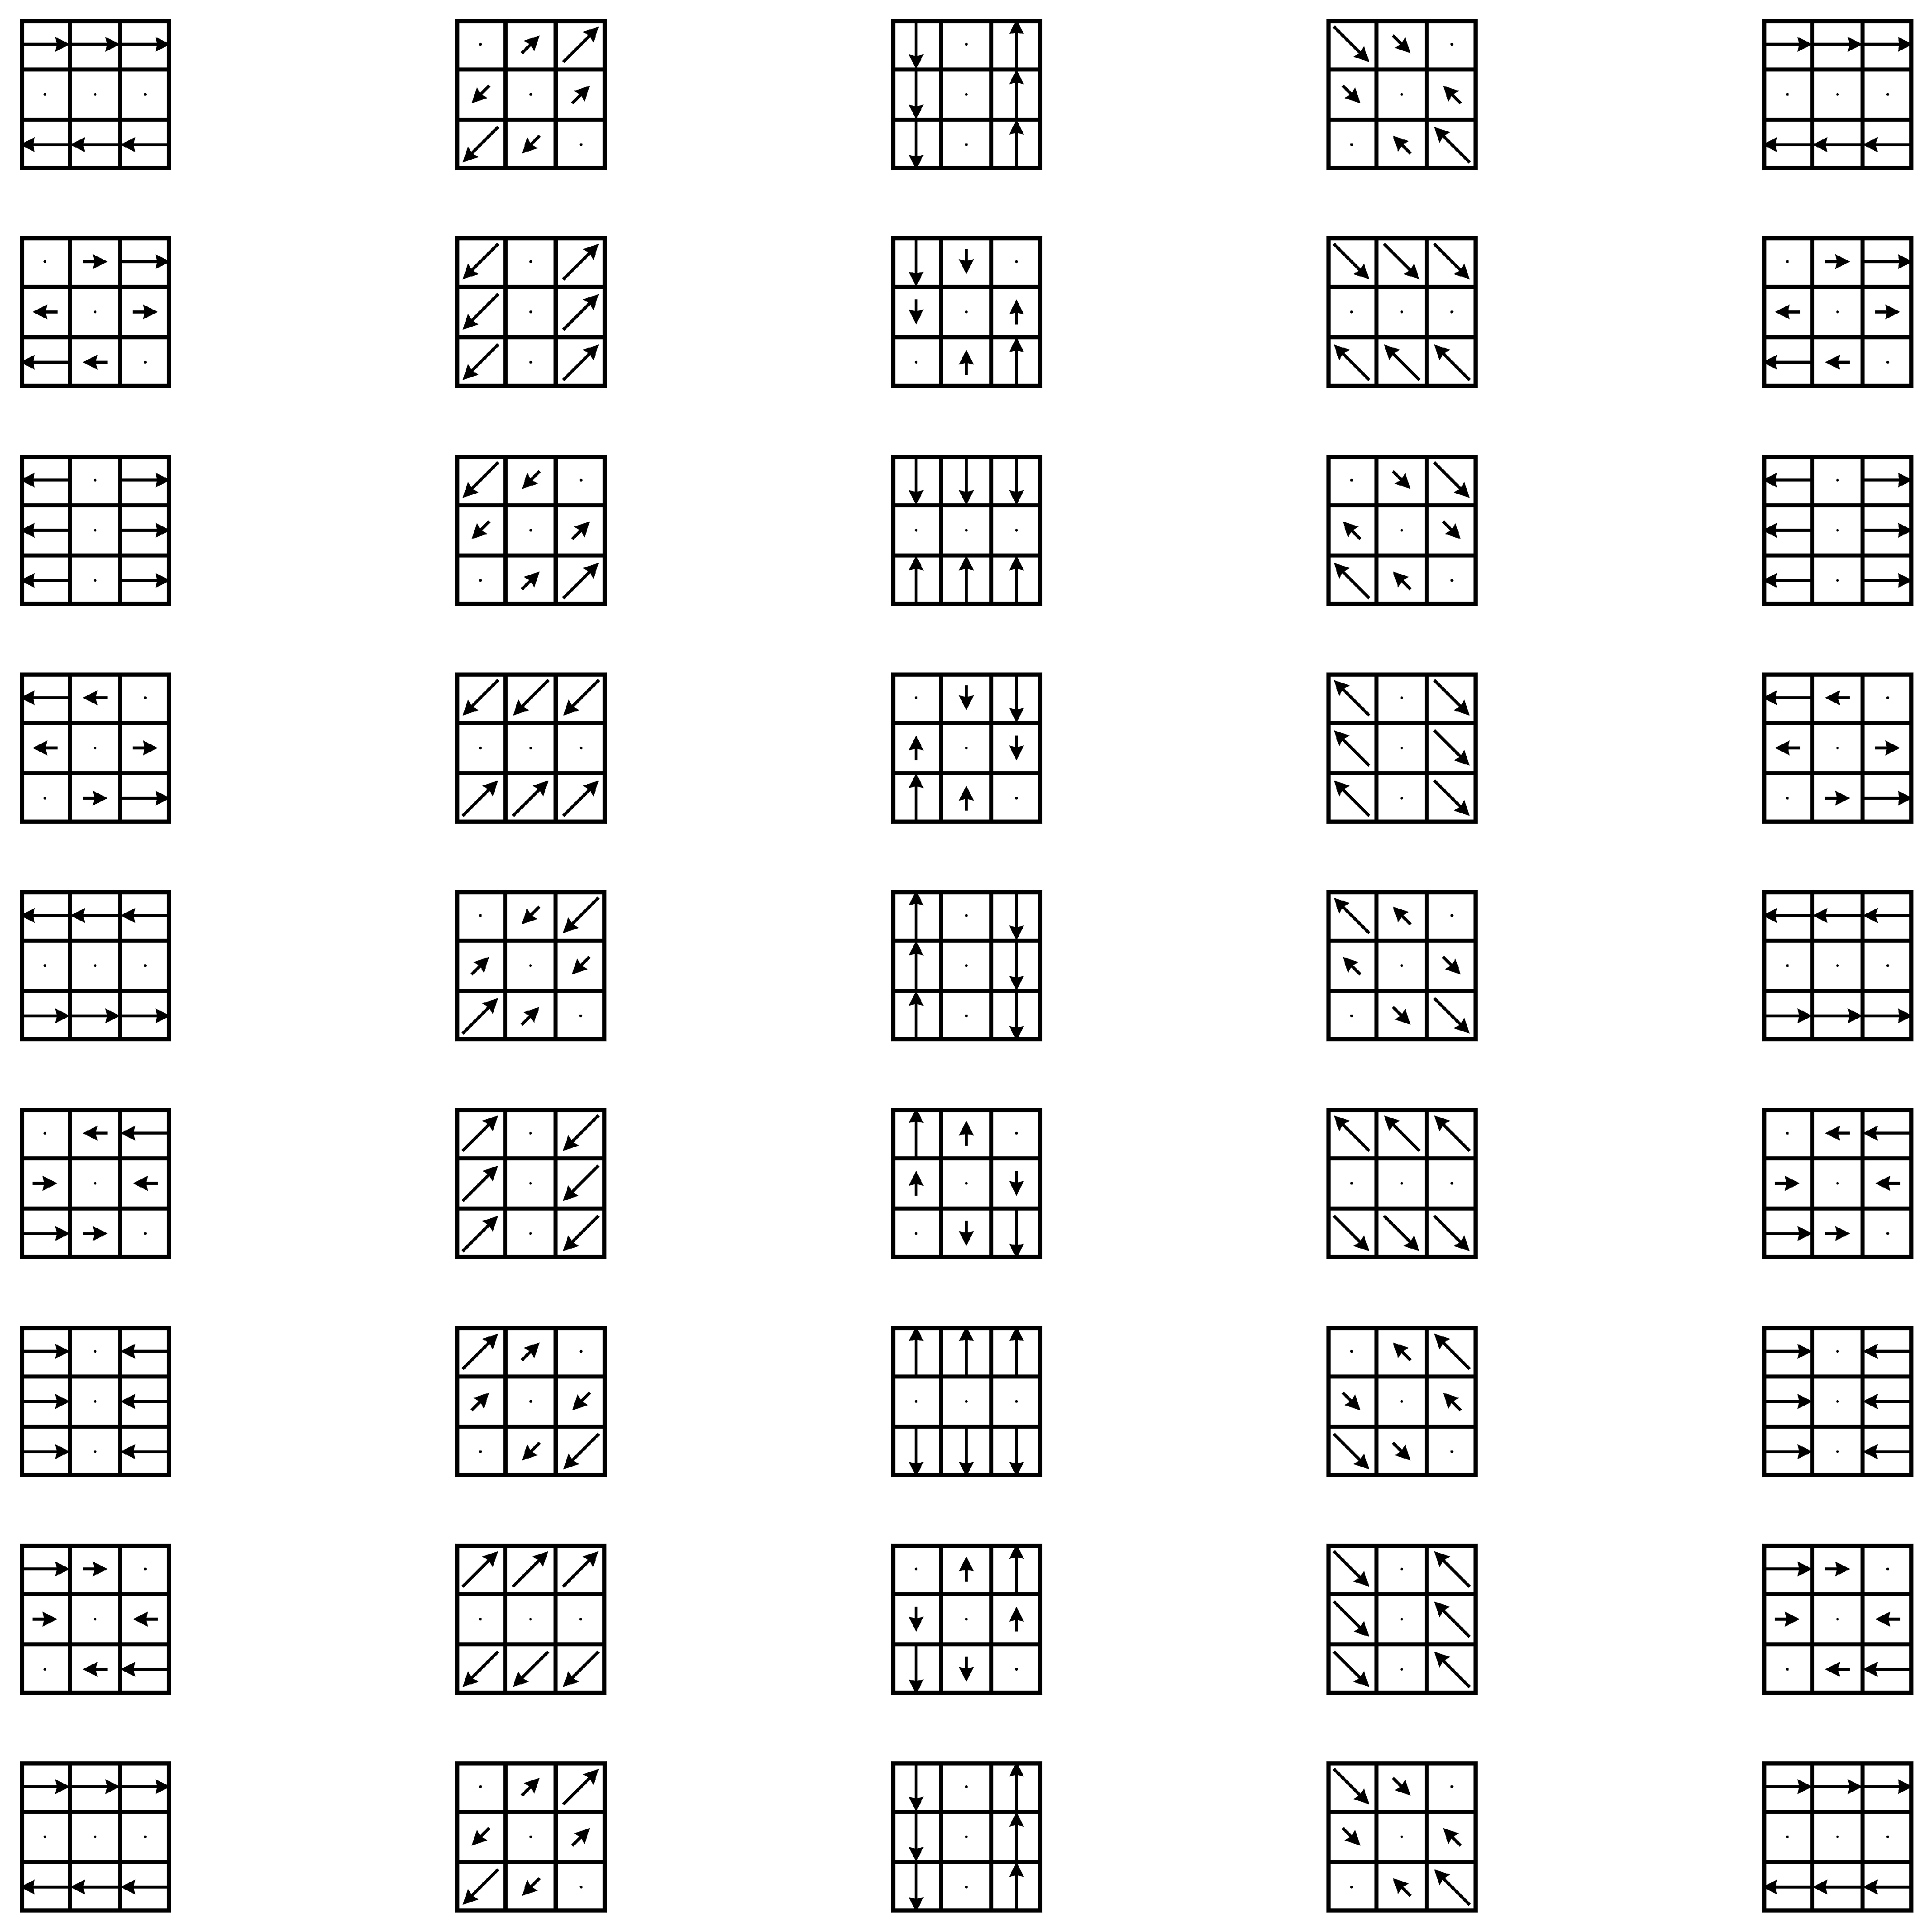

In [49]:
per_row = 5
per_col = 9

theta = np.linspace(0,np.pi,per_row) 
alpha = np.linspace(0,2*np.pi,per_col) 
T, A = np.meshgrid(theta, alpha, indexing='xy')
coords = np.column_stack([T.ravel(), A.ravel()])
r = 0.2*np.random.rand(len(coords))+0.5
data = make_flow_patches((coords[:,1] - coords[:,0])%(2*np.pi), coords[:,0], r = None)

patch_vis = make_patch_visualizer()
file_name = 'Adams_Torus_Shifted.pdf'
save_path = folder_path + file_name
save_path = None
fig = lattice_vis(
    data,
    coords,
    patch_vis,
    per_row=per_row,
    per_col = per_col,
    padding = 0,
    figsize=12,
    thumb_px=350,   
    dpi=350,
    save_path = save_path
)
plt.show()

# Visualize Extended Optical Flow Fibers

In [ ]:
#Get binary step edge patches from a fixed predominant direction

base_angle = np.pi/6


types_list = get_patch_types_list()

data = np.zeros((56, 18))
for k in range(2):
    angle_to_use = (base_angle + k*np.pi) % (2 * np.pi)
    for j, spots in enumerate(types_list):
        data[j + k*28] = make_step_edges(1, spots, angle_range = (angle_to_use,angle_to_use))[0]

inside_patches = data[[16, 0, 14, 1, 18, 3, 19, 2],:]
outside_patches = data[[46, 31, 47, 30, 44, 28, 42, 29],:]
middle_patches = make_flow_patches(np.linspace(0, 2 * np.pi, 8, endpoint=False), base_angle*np.ones(8), r = None)
data = np.concatenate((inside_patches, middle_patches, outside_patches))


patch_vis = make_patch_visualizer()
fig = show_data_vis(data, patch_vis, sampling_method = 'first')
plt.show()

In [ ]:
#Functions for plotting the fiber 

def _fig_to_rgba(fig, dpi=200):
    """
    Render a matplotlib Figure to an RGBA numpy array without writing to disk.
    """
    # draw the renderer
    fig.set_dpi(dpi)
    fig.canvas.draw()

    # RGBA buffer (works reliably across backends)
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = buf.reshape((h, w, 4))

    return img

def _vis_to_image(vis_out, dpi=200):
    """
    Accepts either:
      - a numpy array image (H,W,3) or (H,W,4), dtype uint8 or float in [0,1]
      - a matplotlib Figure
      - a matplotlib Axes (we'll grab its figure)
    Returns an RGBA uint8 image.
    """
    # Case 1: already an image array
    if isinstance(vis_out, np.ndarray):
        img = vis_out
        if img.dtype != np.uint8:
            img = np.clip(img, 0, 1)
            img = (255 * img).astype(np.uint8)
        if img.ndim != 3 or img.shape[2] not in (3, 4):
            raise ValueError("Image array must have shape (H,W,3) or (H,W,4).")
        if img.shape[2] == 3:
            alpha = 255 * np.ones((*img.shape[:2], 1), dtype=np.uint8)
            img = np.concatenate([img, alpha], axis=2)
        return img

    # Case 2: matplotlib Figure
    if isinstance(vis_out, plt.Figure):
        return _fig_to_rgba(vis_out, dpi=dpi)

    # Case 3: matplotlib Axes
    if hasattr(vis_out, "figure") and isinstance(vis_out.figure, plt.Figure):
        return _fig_to_rgba(vis_out.figure, dpi=dpi)

    raise TypeError("vis_func must return a numpy image array, a matplotlib Figure, or a matplotlib Axes.")

def make_patch_visualizer(figsize=2.0, dpi=200):
    """
    Returns a visualization function that takes an optical flow or optical image patch
    and returns a matplotlib figure with a tight visualization (no whitespace margins).
    """

    def _make_full_axes_fig():
        fig = plt.figure(figsize=(figsize, figsize), dpi=dpi)
        # Axes fills the entire canvas: no margins, no padding.
        ax = fig.add_axes([0, 0, 1, 1])
        return fig, ax

    def vis_func(patch_vector):
        length = len(patch_vector)

        # -------- optical image patch: n^2 --------
        if length == int(np.sqrt(length)) ** 2:
            n = int(np.sqrt(length))
            patch_arr = patch_vector.reshape((n, n), order='F')

            # Normalize to [0,1]
            a = np.min(patch_arr)
            b = np.max(patch_arr)
            patch_arr = (patch_arr - a) / (b - a) if b > a else np.zeros_like(patch_arr)

            fig, ax = _make_full_axes_fig()

            # Draw pixels with borders
            for i in range(n):
                for j in range(n):
                    color = patch_arr[i, j]
                    ax.fill_between([j, j + 1], n - i - 1, n - i,
                                    color=str(color), edgecolor='black', linewidth=1)

            ax.set_xlim(0, n)
            ax.set_ylim(0, n)
            ax.set_aspect('equal')
            ax.set_axis_off()

            return fig

        # -------- optical flow patch: 2 n^2 --------
        elif length == 2 * (int(np.sqrt(length / 2)) ** 2):
            n = int(np.sqrt(length / 2))
            patch_arr = patch_vector.reshape((n, n, 2), order='F')[::-1]  # Flip vertically

            # Normalize vectors
            magnitudes = np.linalg.norm(patch_arr, axis=2)
            mmax = np.amax(magnitudes)
            if mmax > 0:
                patch_arr = patch_arr / mmax

            fig, ax = _make_full_axes_fig()

            # Build arrow origins similar to your version
            x, y = np.meshgrid(np.arange(n) + 0.5, np.arange(n) + 0.5)
            x = x - patch_arr[:, :, 0] / 2
            y = y - patch_arr[:, :, 1] / 2

            ax.quiver(
                x, y,
                patch_arr[:, :, 0], patch_arr[:, :, 1],
                scale=n,
                width=0.02,
                headwidth=5,
                headlength=5
            )

            # Turn OFF ticks/grid machinery (it introduces padding),
            # and instead draw the grid manually.
            ax.set_xlim(0, n)
            ax.set_ylim(0, n)
            ax.set_aspect('equal')
            ax.set_axis_off()

            # Manual grid lines
            lw = 2.5
            for k in range(n + 1):
                ax.plot([0, n], [k, k], linewidth=lw, color='black')
                ax.plot([k, k], [0, n], linewidth=lw, color='black')

            # Outer border (thicker)
            rect = mpl_patches.Rectangle((0, 0), n, n, linewidth=2*lw, edgecolor='black', facecolor='none')
            ax.add_patch(rect)

            return fig

        else:
            raise ValueError("Invalid patch_vector length. Must be n^2 or 2n^2 for some integer n.")

    return vis_func    
    
def plot_patches_at_targets(
    x, y, data, ax, vis_func,
    zoom=0.1,
    borders=True,
    colors=None,
    border_lw=2,
    border_pad=0.15,
    dpi=200,
    vis_kwargs=None,
    close_figs=True,
):
    """
    Places visualizations of each data[i] at (x[i], y[i]) on the given ax.

    vis_func: callable like `img_or_fig = vis_func(sample, **vis_kwargs)`
              returning either an image array or a matplotlib Figure/Axes.
    """
    if colors is None:
        colors = ["black"]
    if vis_kwargs is None:
        vis_kwargs = {}

    for i, (xi, yi) in enumerate(zip(x, y)):
        out = vis_func(data[i], **vis_kwargs)
        img = _vis_to_image(out, dpi=dpi)

        # If vis_func returned a Figure and we want to avoid memory leaks:
        if close_figs and isinstance(out, plt.Figure):
            plt.close(out)
        elif close_figs and hasattr(out, "figure") and isinstance(out.figure, plt.Figure):
            # axes case
            plt.close(out.figure)

        im = OffsetImage(img, zoom=zoom)

        if borders:
            color = colors[i % len(colors)]
            ab = AnnotationBbox(
                im, (xi, yi),
                frameon=True,
                bboxprops=dict(
                    edgecolor=color,
                    linewidth=border_lw,
                    boxstyle=f"round,pad={border_pad}"
                )
            )
        else:
            ab = AnnotationBbox(im, (xi, yi), frameon=False)

        ax.add_artist(ab)




In [ ]:
#Show a visualization of a fiber of the extended optical flow torus model

# radii
r_inner, r_middle, r_outer = 3, 5, 7

theta_inner  = np.linspace(0, 2*np.pi, 8, endpoint=False)
theta_middle = np.linspace(0, 2*np.pi, 8, endpoint=False)
theta_outer  = np.linspace(0, 2*np.pi, 8, endpoint=False)

x_inner,  y_inner  = r_inner  * np.cos(theta_inner),  r_inner  * np.sin(theta_inner)
x_middle, y_middle = r_middle * np.cos(theta_middle), r_middle * np.sin(theta_middle)
x_outer,  y_outer  = r_outer  * np.cos(theta_outer),  r_outer  * np.sin(theta_outer)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
ax.axis('off')

colors = list(mcolors.TABLEAU_COLORS.values())

# background
ax.add_patch(Circle((0, 0), r_outer, color='lightgray', fill=True))
ax.add_patch(Circle((0, 0), r_inner, color='white', fill=True))
for c in [
    Circle((0, 0), r_inner,  color='black',    fill=False, linewidth=1, linestyle='--'),
    Circle((0, 0), r_middle, color='darkgray', fill=False, linewidth=1, linestyle='--'),
    Circle((0, 0), r_outer,  color='black',    fill=False, linewidth=1, linestyle='--'),
]:
    ax.add_patch(c)


patch_vis = make_patch_visualizer()    
zoom = 0.08
border_pad = 0.3

plot_patches_at_targets(
    x_inner, y_inner, data[:8], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=True,
    colors=(colors[4:8] + colors[:4]),
    border_pad= border_pad,
    dpi=250,
)

plot_patches_at_targets(
    x_middle, y_middle, data[8:16], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=False,
    dpi=250,
)

plot_patches_at_targets(
    x_outer, y_outer, data[16:], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=True,
    colors=colors,
    border_pad=border_pad,
    dpi=250,
)

ax.set_xlim(-r_outer - 2, r_outer + 2)
ax.set_ylim(-r_outer - 2, r_outer + 2)

#plt.title('Binary Step Edge Optical Flow Patches', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
#Show all the binary step edge range or flow patches
angle = np.pi/6
range_data = make_all_step_edges()
flow_data = make_all_step_edges(angle = angle)

patch_vis = make_patch_visualizer()
fig = show_data_vis(range_data, patch_vis, sampling_method = 'first')
plt.show()

In [ ]:
#Get the patches needed for the visualization
def make_linear_patches(angles):
    e = np.zeros((2,9))
    e[0,[0,3,6]] = 1
    e[1,0:3] = 1
    e[0,[2,5,8]] = -1
    e[1, [6, 7, 8]] = -1
    
    patches = np.cos(angles).reshape(-1,1)*e[0] + np.sin(angles).reshape(-1,1)*e[1]
    patches = patches / np.max(patches, axis = 1).reshape(-1,1)
    return patches

range_data = make_all_step_edges()
inside_patches = range_data[[16, 0, 14, 1, 18, 3, 19, 2]]
outside_patches = range_data[[46, 31, 47, 30, 44, 28, 42, 29]]
middle_patches = make_linear_patches(np.linspace(0, 2 * np.pi, 8, endpoint=False))
data = np.concatenate((inside_patches, middle_patches, outside_patches))

patch_vis = make_patch_visualizer()
fig = show_data_vis(data, patch_vis, sampling_method = 'first')
plt.show()

In [ ]:
#Show a visualization of a fiber of the extended optical flow torus model

# radii
r_inner, r_middle, r_outer = 3, 5, 7

theta_inner  = np.linspace(0, 2*np.pi, 8, endpoint=False)
theta_middle = np.linspace(0, 2*np.pi, 8, endpoint=False)
theta_outer  = np.linspace(0, 2*np.pi, 8, endpoint=False)

x_inner,  y_inner  = r_inner  * np.cos(theta_inner),  r_inner  * np.sin(theta_inner)
x_middle, y_middle = r_middle * np.cos(theta_middle), r_middle * np.sin(theta_middle)
x_outer,  y_outer  = r_outer  * np.cos(theta_outer),  r_outer  * np.sin(theta_outer)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')
ax.axis('off')

colors = ['black'] * 8

# background
ax.add_patch(Circle((0, 0), r_outer, color='lightgray', fill=True))
ax.add_patch(Circle((0, 0), r_inner, color='white', fill=True))
for c in [
    Circle((0, 0), r_inner,  color='black',    fill=False, linewidth=1, linestyle='--'),
    Circle((0, 0), r_middle, color='darkgray', fill=False, linewidth=1, linestyle='--'),
    Circle((0, 0), r_outer,  color='black',    fill=False, linewidth=1, linestyle='--'),
]:
    ax.add_patch(c)


patch_vis = make_patch_visualizer()    
zoom = 0.08
border_pad = 0.3

plot_patches_at_targets(
    x_inner, y_inner, data[:8], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=True,
    colors=(colors[4:8] + colors[:4]),
    border_pad= border_pad,
    dpi=250,
)

plot_patches_at_targets(
    x_middle, y_middle, data[8:16], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=True,
    colors = colors,
    border_pad = border_pad,
    dpi=250,
)

plot_patches_at_targets(
    x_outer, y_outer, data[16:], ax,
    vis_func=patch_vis,
    zoom=zoom,
    borders=True,
    colors=colors,
    border_pad=border_pad,
    dpi=250,
)

ax.set_xlim(-r_outer - 2, r_outer + 2)
ax.set_ylim(-r_outer - 2, r_outer + 2)

#plt.title('Binary Step Edge Optical Flow Patches', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
